# Exemplo 1A: Portfólio Completo com 1 Setor

## Descrição do Exemplo

Este é o **exemplo base** do modelo Credit Risk+:
- **25 contrapartes** com exposições variadas
- **1 setor** (Economia Geral) - todas as contrapartes 100% neste setor
- **Taxas de default variáveis** - cada rating tem taxa média + volatilidade
- **Horizonte de 1 ano** (constant time horizon)

Este notebook reproduz exatamente o **Example 1A** da planilha original do Credit Suisse.

### Objetivo
Calcular a distribuição completa de perdas por default para o portfólio e derivar:
- Perda Esperada (EL)
- Distribuição de perdas (PMF e CDF)
- Percentis de perda (VaR @ 99%, 99.5%, etc.)
- Capital Econômico
- Contribuições de risco por contraparte

In [17]:
# Imports
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from creditriskplus import data
from creditriskplus.simple_model import calculate_loss_distribution

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}' if abs(x) >= 1 else f'{x:.6f}')

def var_interp(cdf, pct, unit_size):
    """Interpolação linear para VaR."""
    idx = np.searchsorted(cdf, pct / 100)
    if idx == 0:
        return 0.0
    if idx >= len(cdf):
        return (len(cdf) - 1) * unit_size
    p_lo, p_hi = cdf[idx - 1], cdf[idx]
    frac = (pct / 100 - p_lo) / (p_hi - p_lo) if p_hi > p_lo else 0.0
    return (idx - 1 + frac) * unit_size

## 1. Carregamento do Portfólio

In [18]:
# Cria o portfólio de Example 1A
portfolio_1a = data.create_example_1a_portfolio()

print("\n=== PORTFÓLIO EXAMPLE 1A ===")
print(f"Total de contrapartes: {len(portfolio_1a)}")
print(f"Exposição total: ${portfolio_1a['exposure'].sum():,.0f}")
print(f"Exposição mín/máx: ${portfolio_1a['exposure'].min():,.0f} / ${portfolio_1a['exposure'].max():,.0f}")

print("\n=== Distribuição por Rating ===")
print(portfolio_1a.groupby('rating')['exposure'].agg(['count', 'sum', 'min', 'max']))


=== PORTFÓLIO EXAMPLE 1A ===
Total de contrapartes: 25
Exposição total: $130,513,072
Exposição mín/máx: $358,475 / $20,238,895

=== Distribuição por Rating ===
        count       sum      min       max
rating                                    
A           1   4727724  4727724   4727724
B           1   7727651  7727651   7727651
C           2  11365431  5517586   5847845
D           5  21520104  3137989   5435457
E           3  31323855  5320364  20238895
F           3  22252928  1799710  15410906
G           4   9619057  1933116   2957685
H           6  21976322   358475   6480322


### Visualização do Portfólio

In [19]:
# Mostra os primeiros e últimos contrapartes
print("\n=== Primeiros 10 Contrapartes ===")
display(portfolio_1a.head(10))

print("\n=== Últimos 10 Contrapartes ===")
display(portfolio_1a.tail(10))


=== Primeiros 10 Contrapartes ===


,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
0,1,358475,H,0.300000,0.150000,1
1,2,1089819,H,0.300000,0.150000,1
2,3,1799710,F,0.100000,0.050000,1
3,4,1933116,G,0.150000,0.075000,1
4,5,2317327,G,0.150000,0.075000,1
5,6,2410929,G,0.150000,0.075000,1
6,7,2652184,H,0.300000,0.150000,1
7,8,2957685,G,0.150000,0.075000,1
8,9,3137989,D,0.050000,0.025000,1
9,10,3204044,D,0.050000,0.025000,1



=== Últimos 10 Contrapartes ===


,obligor_id,exposure,rating,mean_default_rate,std_default_rate,sector_weight_general_economy
15,16,5320364,E,0.075000,0.037500,1
16,17,5435457,D,0.050000,0.025000,1
17,18,5517586,C,0.030000,0.015000,1
18,19,5764596,E,0.075000,0.037500,1
19,20,5847845,C,0.030000,0.015000,1
20,21,6466533,H,0.300000,0.150000,1
21,22,6480322,H,0.300000,0.150000,1
22,23,7727651,B,0.016000,0.008000,1
23,24,15410906,F,0.100000,0.050000,1
24,25,20238895,E,0.075000,0.037500,1


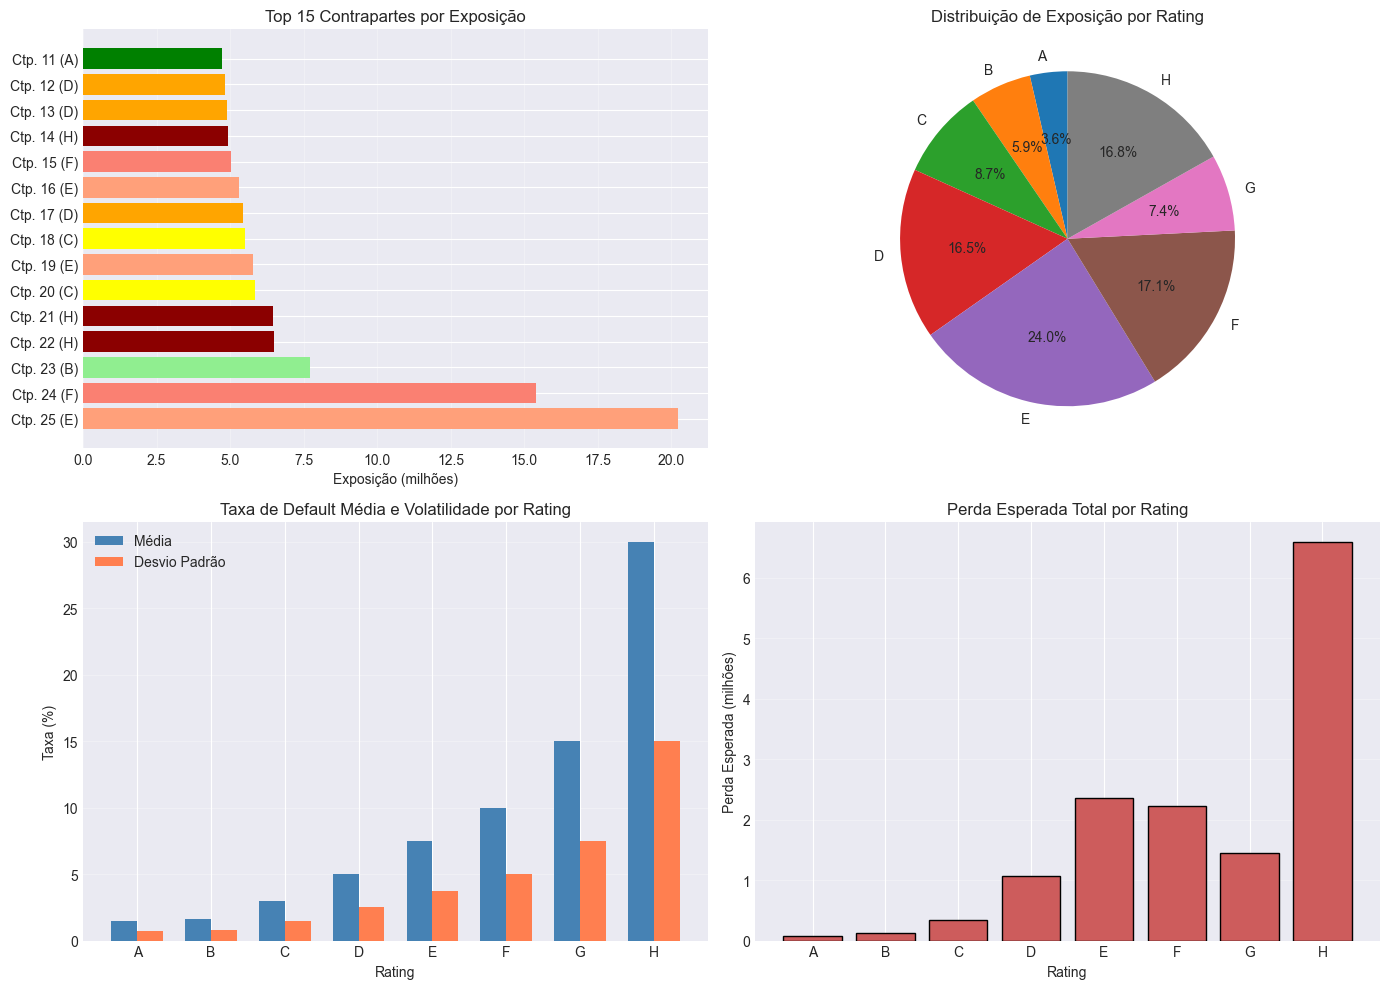


=== Perda Esperada por Rating ===
rating
A   0.070000
B   0.120000
C   0.340000
D          1
E          2
F          2
G          1
H          7
Name: expected_loss, dtype: float64


In [20]:
# Gráficos do portfólio
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Exposições por contraparte (top 15)
top_15 = portfolio_1a.nlargest(15, 'exposure')
colors_by_rating = {'A': 'green', 'B': 'lightgreen', 'C': 'yellow', 'D': 'orange',
                     'E': 'lightsalmon', 'F': 'salmon', 'G': 'red', 'H': 'darkred'}
colors = [colors_by_rating[r] for r in top_15['rating']]

axes[0, 0].barh(range(len(top_15)), top_15['exposure'] / 1e6, color=colors)
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels([f"Ctp. {id} ({r})" for id, r in zip(top_15['obligor_id'], top_15['rating'])])
axes[0, 0].set_xlabel('Exposição (milhões)')
axes[0, 0].set_title('Top 15 Contrapartes por Exposição')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Distribuição por rating (exposição total)
rating_exposure = portfolio_1a.groupby('rating')['exposure'].sum().sort_index()
axes[0, 1].pie(rating_exposure, labels=rating_exposure.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Distribuição de Exposição por Rating')

# 3. Taxa de default média por rating
rating_stats = portfolio_1a.groupby('rating')[['mean_default_rate', 'std_default_rate']].mean()
x_pos = np.arange(len(rating_stats))
width = 0.35
axes[1, 0].bar(x_pos - width/2, rating_stats['mean_default_rate']*100, width, label='Média', color='steelblue')
axes[1, 0].bar(x_pos + width/2, rating_stats['std_default_rate']*100, width, label='Desvio Padrão', color='coral')
axes[1, 0].set_xlabel('Rating')
axes[1, 0].set_ylabel('Taxa (%)')
axes[1, 0].set_title('Taxa de Default Média e Volatilidade por Rating')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(rating_stats.index)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Perda esperada por rating
portfolio_1a['expected_loss'] = portfolio_1a['exposure'] * portfolio_1a['mean_default_rate']
rating_el = portfolio_1a.groupby('rating')['expected_loss'].sum()
axes[1, 1].bar(rating_el.index, rating_el.values / 1e6, color='indianred', edgecolor='black')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Perda Esperada (milhões)')
axes[1, 1].set_title('Perda Esperada Total por Rating')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== Perda Esperada por Rating ===")
print((rating_el / 1e6).round(2))

## 2. Configuração e Cálculo do Modelo Credit Risk+

In [21]:
# Parâmetros do modelo (recuperação = 0 no Example 1A)
net_exposures = portfolio_1a['exposure'].values
mean_dr = portfolio_1a['mean_default_rate'].values
std_dr = portfolio_1a['std_default_rate'].values
recovery = np.zeros(len(portfolio_1a))

unit_size = float(np.ceil(net_exposures.max() / 100))
max_loss_dollars = 150_000_000

print(f"Parâmetros do modelo:")
print(f"  - Unit size (L): ${unit_size:,.0f}")
print(f"  - Max loss:      ${max_loss_dollars:,.0f}")
print(f"  - Portfólio:     {len(portfolio_1a)} contrapartes, 1 setor")

Parâmetros do modelo:
  - Unit size (L): $202,389
  - Max loss:      $150,000,000
  - Portfólio:     25 contrapartes, 1 setor


### Cálculo da Distribuição de Perdas

O modelo usa a **recursão de Apêndice A** (Eq 25-26 / 79-80) para calcular a distribuição completa de perdas.

In [22]:
# Calcula a distribuição de perdas
print("Calculando distribuição de perdas...")
pmf, el = calculate_loss_distribution(
    exposures=net_exposures,
    mean_default_rates=mean_dr,
    std_default_rates=std_dr,
    recovery_rates=recovery,
    unit_size=unit_size,
    max_loss_dollars=max_loss_dollars,
)

loss_values = np.arange(len(pmf)) * unit_size
cdf = np.cumsum(pmf)
loss_variance = ((loss_values - el) ** 2 * pmf).sum()
loss_std = np.sqrt(loss_variance)

print(f"✓ Distribuição calculada: {np.count_nonzero(pmf)} estados possíveis")
print(f"\n=== ESTATÍSTICAS DO PORTFÓLIO ===")
print(f"Exposição Total:     ${net_exposures.sum():>15,.0f}")
print(f"Perda Esperada:      ${el:>15,.0f}")
print(f"Volatilidade (σ):    ${loss_std:>15,.0f}")
print(f"Variância (σ²):      ${loss_variance:>15,.0f}")

Calculando distribuição de perdas...
✓ Distribuição calculada: 738 estados possíveis

=== ESTATÍSTICAS DO PORTFÓLIO ===
Exposição Total:     $    130,513,072
Perda Esperada:      $     14,221,830
Volatilidade (σ):    $     12,668,553
Variância (σ²):      $160,492,241,532,888


## 3. Distribuição de Perdas

In [23]:
# Tabela de percentis
percentiles_list = [50, 75, 95, 97.5, 99, 99.5, 99.75, 99.9]
percentile_losses = {p: var_interp(cdf, p, unit_size) for p in percentiles_list}

var_99 = percentile_losses[99]
ec_99 = var_99 - el

print("\n=== PERCENTIS DE PERDA ===")
percentile_df = pd.DataFrame({
    'Percentil': percentiles_list,
    'Perda': [percentile_losses[p] for p in percentiles_list],
    'Desvios σ': [(percentile_losses[p] - el) / loss_std for p in percentiles_list],
})
percentile_df['Perda'] = percentile_df['Perda'].apply(lambda x: f"${x:,.0f}")
percentile_df['Desvios σ'] = percentile_df['Desvios σ'].apply(lambda x: f"{x:.2f}σ")
display(percentile_df)

print(f"\n99º Percentil (VaR):     ${var_99:>15,.0f}")
print(f"Capital Econômico (99%): ${ec_99:>15,.0f}")


=== PERCENTIS DE PERDA ===


,Percentil,Perda,Desvios σ
0,50,"$11,089,450",-0.25σ
1,75,"$20,498,056",0.50σ
2,95,"$38,908,440",1.95σ
3,98,"$46,152,034",2.52σ
4,99,"$55,311,280",3.24σ
5,100,"$62,032,737",3.77σ
6,100,"$68,611,658",4.29σ
7,100,"$77,131,338",4.97σ



99º Percentil (VaR):     $     55,311,280
Capital Econômico (99%): $     41,089,450


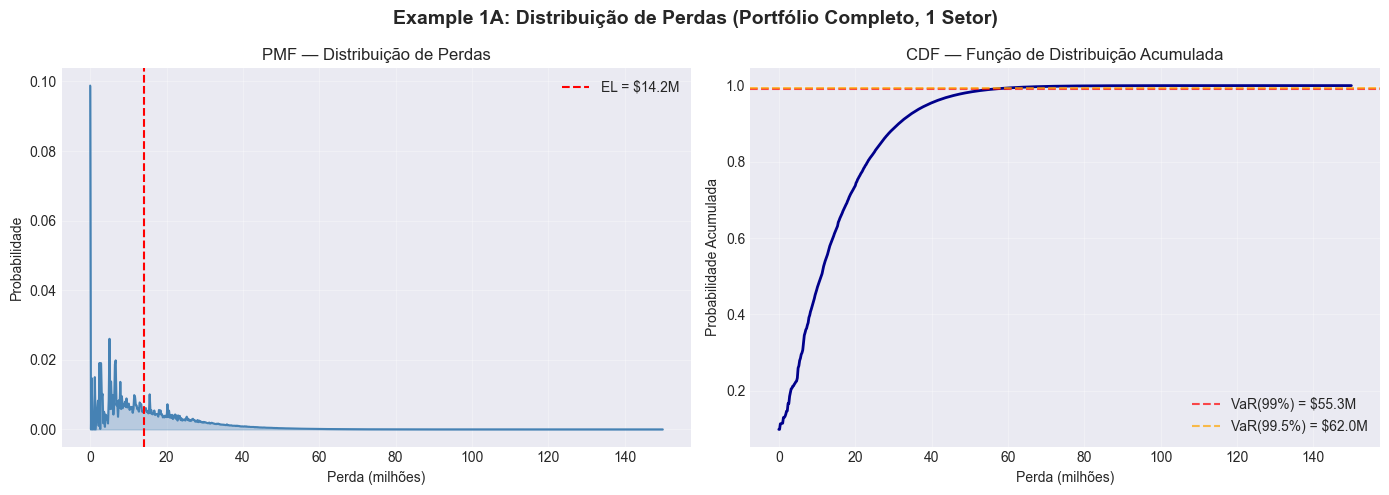

In [24]:
# Visualiza a distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

max_plot = min(int(max_loss_dollars / unit_size), len(pmf) - 1)
x_m = loss_values[:max_plot + 1] / 1e6
y_pmf = pmf[:max_plot + 1]
y_cdf = cdf[:max_plot + 1]

# PMF
axes[0].plot(x_m, y_pmf, color='steelblue', linewidth=1.5)
axes[0].fill_between(x_m, 0, y_pmf, alpha=0.3, color='steelblue')
axes[0].axvline(x=el / 1e6, color='red', linestyle='--', label=f'EL = ${el/1e6:.1f}M')
axes[0].set_xlabel('Perda (milhões)')
axes[0].set_ylabel('Probabilidade')
axes[0].set_title('PMF — Distribuição de Perdas')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CDF
axes[1].plot(x_m, y_cdf, color='darkblue', linewidth=2)
for pct, color in [(99, 'red'), (99.5, 'orange')]:
    v = var_interp(cdf, pct, unit_size) / 1e6
    axes[1].axhline(y=pct / 100, color=color, linestyle='--', alpha=0.7, label=f'VaR({pct}%) = ${v:.1f}M')
axes[1].set_xlabel('Perda (milhões)')
axes[1].set_ylabel('Probabilidade Acumulada')
axes[1].set_title('CDF — Função de Distribuição Acumulada')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle('Example 1A: Distribuição de Perdas (Portfólio Completo, 1 Setor)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

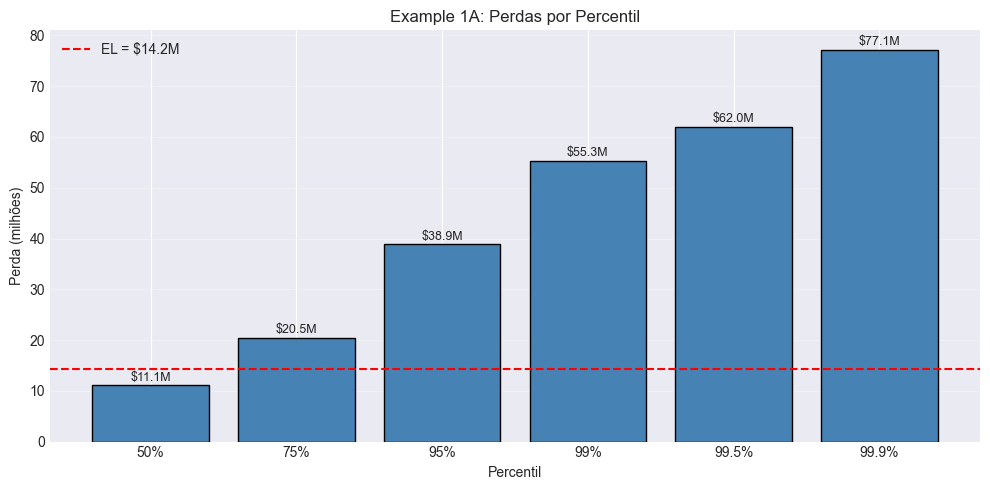

In [25]:
# Visualiza percentis
pct_plot = [50, 75, 95, 99, 99.5, 99.9]
values_m = [var_interp(cdf, p, unit_size) / 1e6 for p in pct_plot]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([f'{p}%' for p in pct_plot], values_m, color='steelblue', edgecolor='black')
ax.axhline(y=el / 1e6, color='red', linestyle='--', label=f'EL = ${el/1e6:.1f}M')
for bar, val in zip(bars, values_m):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'${val:.1f}M', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Percentil')
ax.set_ylabel('Perda (milhões)')
ax.set_title('Example 1A: Perdas por Percentil')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Contribuições de Risco por Contraparte

In [26]:
# Calcula contribuições de risco por contraparte (Apêndice A, Eq 98-103)
# Decomposição aditiva: RC_A = EL_A + (VaR - EL) * (μ_A / μ_total)
v_bands = np.maximum(np.ceil(net_exposures / unit_size).astype(int), 1)
epsilons = net_exposures * mean_dr / unit_size
mus_per_obligor = epsilons / v_bands  # contribuição de cada contraparte ao μ total
mu_total = mus_per_obligor.sum()

el_contrib = net_exposures * mean_dr  # EL_A = p_A * E_A
rc_99 = el_contrib + (var_99 - el) * (mus_per_obligor / mu_total)

rc_df = pd.DataFrame({
    'obligor_id': portfolio_1a['obligor_id'].values,
    'exposure': net_exposures,
    'rating': portfolio_1a['rating'].values,
    'expected_loss': el_contrib,
    'risk_contribution_99pct': rc_99,
})

print("\n=== CONTRIBUIÇÕES DE RISCO ===")
print(f"\nSoma das EL por contraparte:          ${rc_df['expected_loss'].sum():,.0f}")
print(f"Perda Esperada do portfólio:          ${el:,.0f}")
print(f"\nSoma das RC @ 99º percentil:          ${rc_df['risk_contribution_99pct'].sum():,.0f}")
print(f"VaR(99%) do portfólio:                ${var_99:,.0f}")
print(f"Diferença (erro de arredondamento):   ${var_99 - rc_df['risk_contribution_99pct'].sum():,.0f}")


=== CONTRIBUIÇÕES DE RISCO ===

Soma das EL por contraparte:          $14,221,863
Perda Esperada do portfólio:          $14,221,830

Soma das RC @ 99º percentil:          $55,311,313
VaR(99%) do portfólio:                $55,311,280
Diferença (erro de arredondamento):   $-33


In [27]:
# Mostra as contribuições de risco das top 15 contrapartes
rc_top15 = rc_df.nlargest(15, 'risk_contribution_99pct')[
    ['obligor_id', 'exposure', 'rating', 'expected_loss', 'risk_contribution_99pct']
]

print("\n=== TOP 15 CONTRAPARTES POR CONTRIBUIÇÃO DE RISCO (99º percentil) ===")
rc_top15_display = rc_top15.copy()
rc_top15_display['exposure'] = rc_top15_display['exposure'].apply(lambda x: f"${x:,.0f}")
rc_top15_display['expected_loss'] = rc_top15_display['expected_loss'].apply(lambda x: f"${x:,.0f}")
rc_top15_display['risk_contribution_99pct'] = rc_top15_display['risk_contribution_99pct'].apply(lambda x: f"${x:,.0f}")
rc_top15_display.columns = ['Contraparte', 'Exposição', 'Rating', 'Perda Esperada', 'RC (99%)']
display(rc_top15_display.reset_index(drop=True))


=== TOP 15 CONTRAPARTES POR CONTRIBUIÇÃO DE RISCO (99º percentil) ===


,Contraparte,Exposição,Rating,Perda Esperada,RC (99%)
0,21,"$6,466,533",H,"$1,939,960","$5,866,744"
1,22,"$6,480,322",H,"$1,944,097","$5,760,007"
2,14,"$4,928,989",H,"$1,478,697","$5,309,884"
3,7,"$2,652,184",H,"$795,655","$4,476,870"
4,2,"$1,089,819",H,"$326,946","$3,856,490"
5,1,"$358,475",H,"$107,542","$3,590,470"
6,24,"$15,410,906",F,"$1,541,091","$2,837,469"
7,25,"$20,238,895",E,"$1,517,917","$2,501,118"
8,8,"$2,957,685",G,"$443,653","$2,359,435"
9,6,"$2,410,929",G,"$361,639","$2,313,679"


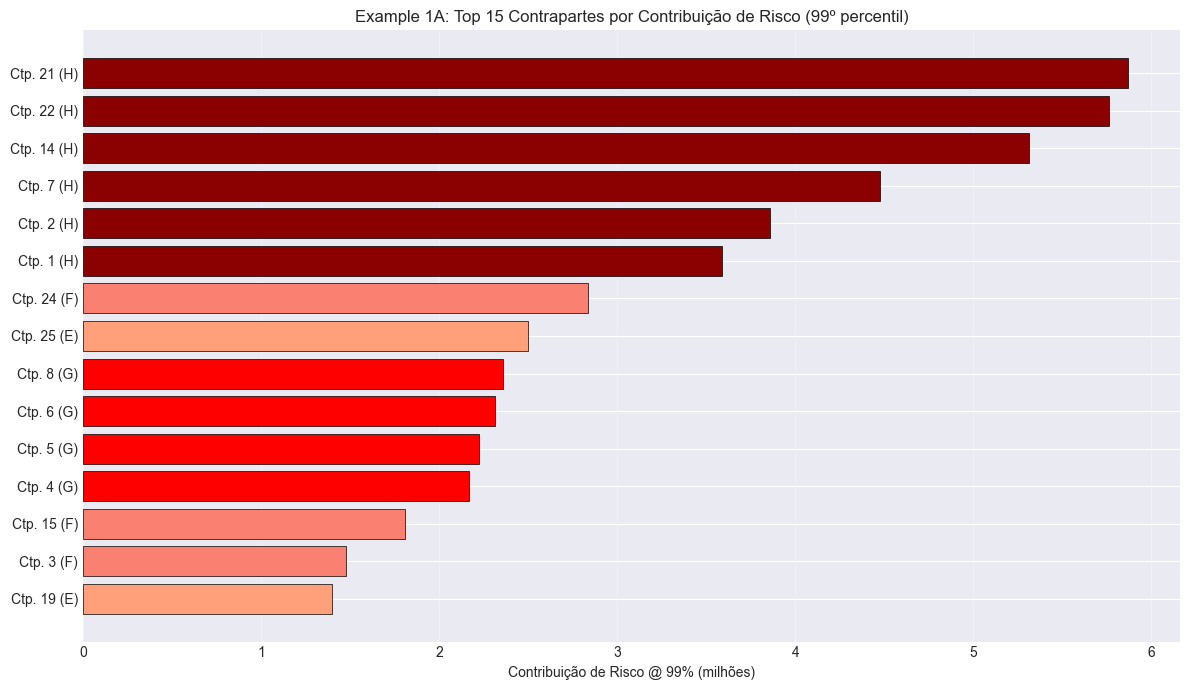

In [28]:
# Visualiza contribuições de risco (top 15)
rc_sorted = rc_df.nlargest(15, 'risk_contribution_99pct').sort_values('risk_contribution_99pct')

fig, ax = plt.subplots(figsize=(12, 7))
colors_rc = [colors_by_rating.get(r, 'gray') for r in rc_sorted['rating']]
bars = ax.barh(
    [f"Ctp. {i} ({r})" for i, r in zip(rc_sorted['obligor_id'], rc_sorted['rating'])],
    rc_sorted['risk_contribution_99pct'] / 1e6,
    color=colors_rc,
    edgecolor='black', linewidth=0.5,
)
ax.set_xlabel('Contribuição de Risco @ 99% (milhões)')
ax.set_title('Example 1A: Top 15 Contrapartes por Contribuição de Risco (99º percentil)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Tabela Completa de Resultados

In [29]:
# Tabela completa de todas as 25 contrapartes
results = rc_df.copy().sort_values('risk_contribution_99pct', ascending=False)

print("\n=== RESULTADOS COMPLETOS — TODAS AS 25 CONTRAPARTES ===")
results_display = results.copy()
results_display['exposure'] = results_display['exposure'].apply(lambda x: f"${x:,.0f}")
results_display['expected_loss'] = results_display['expected_loss'].apply(lambda x: f"${x:,.0f}")
results_display['risk_contribution_99pct'] = results_display['risk_contribution_99pct'].apply(lambda x: f"${x:,.0f}")
results_display.columns = ['Contraparte', 'Exposição', 'Rating', 'Perda Esperada', 'RC (99%)']
display(results_display.reset_index(drop=True))


=== RESULTADOS COMPLETOS — TODAS AS 25 CONTRAPARTES ===


,Contraparte,Exposição,Rating,Perda Esperada,RC (99%)
0,21,"$6,466,533",H,"$1,939,960","$5,866,744"
1,22,"$6,480,322",H,"$1,944,097","$5,760,007"
2,14,"$4,928,989",H,"$1,478,697","$5,309,884"
3,7,"$2,652,184",H,"$795,655","$4,476,870"
4,2,"$1,089,819",H,"$326,946","$3,856,490"
5,1,"$358,475",H,"$107,542","$3,590,470"
6,24,"$15,410,906",F,"$1,541,091","$2,837,469"
7,25,"$20,238,895",E,"$1,517,917","$2,501,118"
8,8,"$2,957,685",G,"$443,653","$2,359,435"
9,6,"$2,410,929",G,"$361,639","$2,313,679"


## 6. Análise de Concentração


=== ANÁLISE DE CONCENTRAÇÃO ===

Top 1 contraparte:     10.61% da RC total (cumsum:  10.61%)
Top 5 contrapartes:    45.69% da RC total (cumsum:  45.69%)
Top 10 contrapartes:   70.28% da RC total (cumsum:  70.28%)
Top 15 contrapartes:   86.69% da RC total (cumsum:  86.69%)


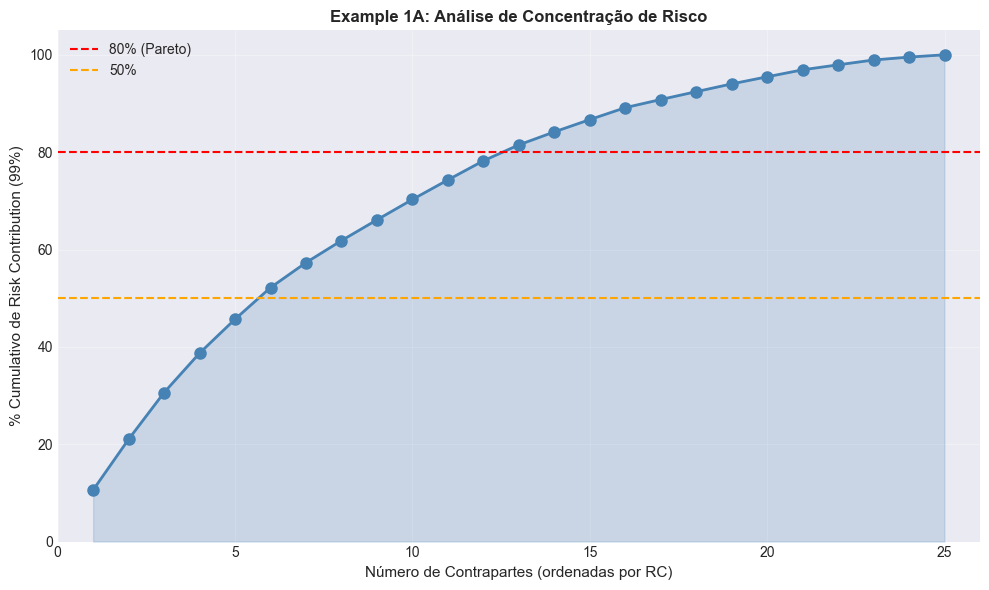


→ 12 contrapartes concentram 80% do risco


In [30]:
# Análise de concentração
results['rc_pct'] = results['risk_contribution_99pct'] / results['risk_contribution_99pct'].sum() * 100
results['cumsum_rc_pct'] = results['rc_pct'].cumsum()

print("\n=== ANÁLISE DE CONCENTRAÇÃO ===")
print(f"\nTop 1 contraparte:    {results['rc_pct'].iloc[0]:>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[0]:>6.2f}%)")
print(f"Top 5 contrapartes:   {results['rc_pct'].iloc[:5].sum():>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[4]:>6.2f}%)")
print(f"Top 10 contrapartes:  {results['rc_pct'].iloc[:10].sum():>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[9]:>6.2f}%)")
print(f"Top 15 contrapartes:  {results['rc_pct'].iloc[:15].sum():>6.2f}% da RC total (cumsum: {results['cumsum_rc_pct'].iloc[14]:>6.2f}%)")

# Gráfico de concentração
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, 26), results['cumsum_rc_pct'].values, marker='o', linewidth=2, markersize=8, color='steelblue')
ax.axhline(y=80, color='red', linestyle='--', label='80% (Pareto)')
ax.axhline(y=50, color='orange', linestyle='--', label='50%')
ax.fill_between(range(1, 26), 0, results['cumsum_rc_pct'].values, alpha=0.2, color='steelblue')
ax.set_xlabel('Número de Contrapartes (ordenadas por RC)', fontsize=11)
ax.set_ylabel('% Cumulativo de Risk Contribution (99%)', fontsize=11)
ax.set_title('Example 1A: Análise de Concentração de Risco', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_xlim([0, 26])
ax.set_ylim([0, 105])
plt.tight_layout()
plt.show()

print(f"\n→ {(results['cumsum_rc_pct'] <= 80).sum()} contrapartes concentram 80% do risco")

## 7. Sumário Final

In [31]:
# Sumário final
print("\n" + "=" * 60)
print("SUMÁRIO FINAL — EXAMPLE 1A")
print("=" * 60)
print(f"\nPortfólio:")
print(f"  Total de Exposição:     ${net_exposures.sum():>15,.0f}")
print(f"  Total de Contrapartes:  {len(portfolio_1a):>15}")
print(f"  Total de Setores:       {'1':>15}")

print(f"\nEstatísticas de Perda:")
print(f"  Perda Esperada:         ${el:>15,.0f}")
print(f"  Volatilidade (σ):       ${loss_std:>15,.0f}")
print(f"  Variância (σ²):         ${loss_variance:>15,.0f}")

print(f"\nPercentis de Perda (VaR):")
for pct in [50, 75, 95, 97.5, 99, 99.5, 99.75, 99.9]:
    loss = var_interp(cdf, pct, unit_size)
    excess = loss - el
    print(f"  {pct:>5.2f}º percentil:        ${loss:>15,.0f}  (excesso: ${excess:>12,.0f})")

print(f"\nCapital Econômico:")
print(f"  EC @ 99º percentil:     ${ec_99:>15,.0f}")
print(f"  EC / Exposição Total:   {ec_99 / net_exposures.sum() * 100:>15.2f}%")

print("\n" + "=" * 60)


SUMÁRIO FINAL — EXAMPLE 1A

Portfólio:
  Total de Exposição:     $    130,513,072
  Total de Contrapartes:               25
  Total de Setores:                     1

Estatísticas de Perda:
  Perda Esperada:         $     14,221,830
  Volatilidade (σ):       $     12,668,553
  Variância (σ²):         $160,492,241,532,888

Percentis de Perda (VaR):
  50.00º percentil:        $     11,089,450  (excesso: $  -3,132,380)
  75.00º percentil:        $     20,498,056  (excesso: $   6,276,226)
  95.00º percentil:        $     38,908,440  (excesso: $  24,686,610)
  97.50º percentil:        $     46,152,034  (excesso: $  31,930,204)
  99.00º percentil:        $     55,311,280  (excesso: $  41,089,450)
  99.50º percentil:        $     62,032,737  (excesso: $  47,810,907)
  99.75º percentil:        $     68,611,658  (excesso: $  54,389,828)
  99.90º percentil:        $     77,131,338  (excesso: $  62,909,508)

Capital Econômico:
  EC @ 99º percentil:     $     41,089,450
  EC / Exposição Total:   

## 8. Validação contra o Documento Original

Vamos verificar se os nossos resultados batem com a planilha original.

In [32]:
# Validação contra a planilha original (CreditRisk+.xls)
expected = {
    'EL':    14_221_863,
    'VaR99': 55_311_503,
    'EC99':  55_311_503 - 14_221_863,  # 41,089,640
}

print("\n=== VALIDAÇÃO CONTRA PLANILHA ORIGINAL ===")
print(f"\nPerda Esperada (EL):")
print(f"  Calculado: ${el:>15,.0f}")
print(f"  Esperado:  ${expected['EL']:>15,.0f}")
print(f"  Erro:      {(el - expected['EL']) / expected['EL'] * 100:>15.4f}%")

print(f"\nVaR @ 99º percentil:")
print(f"  Calculado: ${var_99:>15,.0f}")
print(f"  Esperado:  ${expected['VaR99']:>15,.0f}")
print(f"  Erro:      {(var_99 - expected['VaR99']) / expected['VaR99'] * 100:>15.4f}%")

print(f"\nCapital Econômico @ 99º percentil:")
print(f"  Calculado: ${ec_99:>15,.0f}")
print(f"  Esperado:  ${expected['EC99']:>15,.0f}")
print(f"  Erro:      {(ec_99 - expected['EC99']) / expected['EC99'] * 100:>15.4f}%")

el_err = abs(el - expected['EL']) / expected['EL']
var_err = abs(var_99 - expected['VaR99']) / expected['VaR99']
if el_err < 0.001 and var_err < 0.001:
    print("\n✓ VALIDAÇÃO APROVADA: Resultados batem com a planilha original (erro < 0.1%)!")
else:
    print(f"\n⚠ Diferenças observadas — EL: {el_err*100:.4f}%, VaR: {var_err*100:.4f}%")


=== VALIDAÇÃO CONTRA PLANILHA ORIGINAL ===

Perda Esperada (EL):
  Calculado: $     14,221,830
  Esperado:  $     14,221,863
  Erro:              -0.0002%

VaR @ 99º percentil:
  Calculado: $     55,311,280
  Esperado:  $     55,311,503
  Erro:              -0.0004%

Capital Econômico @ 99º percentil:
  Calculado: $     41,089,450
  Esperado:  $     41,089,640
  Erro:              -0.0005%

✓ VALIDAÇÃO APROVADA: Resultados batem com a planilha original (erro < 0.1%)!
